[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Optimizer077/jev-learning-course/blob/main/notebooks/06_architecture_and_training_lab.ipynb)

# 6 · Architecture and training: what we can actually explain

**Path:** Optional advanced lab  
**Before you start:** Lesson 02; matrix multiplication and softmax

[Course home](../README.md) · [Course outline](../docs/COURSE.md) · [Setup help](../docs/SETUP.md) · [Glossary](../docs/GLOSSARY.md)

## The idea before the code

Several different mechanisms can produce bounded decisions. We experiment with generic candidate scoring and attention to understand the possibilities, not to reveal Jev’s unpublished design.

**Your first pass:** Read each diagram and its explanation before the code. The loss derivation is optional.

### Words you need for this lesson

| Word | Everyday meaning |
|---|---|
| **Representation** | The numbers used to describe an input. |
| **Attention** | A calculation that combines information from positions in an input. |
| **Mask** | A rule specifying which positions can read which others. |

## Goal
Connect the interface to concrete computational ideas while keeping the evidence boundary visible.
**35–45 minutes · intermediate.** Prerequisites: vectors, matrix multiplication, and softmax from lesson 2.

TypeSafe describes parallel question evaluation and decision-oriented training.
Its public overview does not supply the full architecture or RLCD algorithm.
[AI primer](https://docs.typesafe.ai/introduction/machine-learning-primer) ·
[Parallel questions pattern](https://docs.typesafe.ai/patterns/fan-out).

We will build **our own generic mechanisms**: score descriptions, isolate questions with an attention
mask, and compare objectives. These are demonstrations of possibilities, not claims about Jev's implementation.

## Setup
All computations use NumPy, random or author-chosen toy vectors, and no downloaded model weights.

In [1]:
# Find the included teaching helpers from the course folder.
from pathlib import Path
import sys
REQUIRED_FILES = ("src/lab_core.py", "src/tutorial_utils.py", "src/torch_lab.py",
                  "data/tickets.json", "data/torch_toy.json",
                  "assets/decision-flow.png", "assets/question-types.png",
                  "assets/calibration-counts.png", "assets/data-splits.png", "assets/word-order.png")
COURSE_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                    if all((p / name).is_file() for name in REQUIRED_FILES)), None)
# Colab opens a single notebook; fetch its companion code and fictional data.
if COURSE_ROOT is None:
    try:
        import google.colab
    except ImportError:
        pass
    else:
        import subprocess
        COURSE_ROOT = Path("/content/jev-learning-course")
        if COURSE_ROOT.exists() and not all((COURSE_ROOT / name).is_file() for name in REQUIRED_FILES):
            raise FileNotFoundError("The cached Colab course is incomplete. Start a fresh runtime and run all again.")
        if not COURSE_ROOT.exists():
            subprocess.run(["git", "clone", "--depth", "1",
                            "https://github.com/Optimizer077/jev-learning-course.git",
                            str(COURSE_ROOT)], check=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Extract the complete course and open it from its folder.")
if str(COURSE_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
from tutorial_utils import setup, show_figure, table, BLUE, ORANGE, GREY
setup()

from lab_core import softmax

## Steps
### 1. Fixed class heads versus scoring descriptions
The linear model in lesson 2 has one trained column per class. It cannot suddenly learn a fourth
class merely because you add a new name. An alternative pattern embeds **both the state and the
candidate description**, then computes compatibility. Changing descriptions changes the scored inputs.

The simple example below is only word overlap. A learned encoder or cross-encoder can be much
richer. [BERT](https://aclanthology.org/N19-1423/) is a primary example of a pretrained language
representation adapted for downstream classification; it is not evidence that Jev is BERT.

In [2]:
from lab_core import vocabulary, vectorise
state = 'the export button crashes and the browser freezes'
descriptions = {
    'billing': 'invoice payment refund charge card',
    'technical': 'export button crashes browser freezes error',
    'account': 'login password email access verification',
}
# There is no fitting here: this vocabulary only defines common coordinates for a lexical demo.
vocab = vocabulary([state, *descriptions.values()])
state_vector = vectorise([state], vocab)[0]
candidate_vectors = vectorise(list(descriptions.values()), vocab)
overlap_scores = candidate_vectors @ state_vector
relative_weights = softmax(overlap_scores)
table(['Candidate', 'Shared-word count', 'Softmax weight (not calibrated)'],
      [(key, int(score), f'{p:.3f}') for key, score, p in zip(descriptions, overlap_scores, relative_weights)])

Candidate,Shared-word count,Softmax weight (not calibrated)
billing,0,0.007
technical,5,0.987
account,0,0.007


### 2. Change the answer set
Softmax probabilities are relative to the available candidates. Duplicating a strong option divides
probability mass even though the evidence has not changed. This is a generic softmax property;
we are not asserting how Jev responds to duplicate descriptions.

In [3]:
duplicate_scores = np.append(overlap_scores, overlap_scores[1])
duplicate_weights = softmax(duplicate_scores)
print('Technical weight before duplicate:', round(float(relative_weights[1]), 3))
print('Technical weight after duplicate:', round(float(duplicate_weights[1]), 3))
print('Duplicate technical weight:', round(float(duplicate_weights[-1]), 3))
assert duplicate_weights[1] < relative_weights[1]

Technical weight before duplicate: 0.987
Technical weight after duplicate: 0.497
Duplicate technical weight: 0.497


This explains why closed-set selection and “does any candidate fit?” are different questions.
If every option is poor, a normalized distribution still sums to one. Add a none-of-the-above
option or use a separate applicability test, and evaluate it on out-of-domain inputs.

### 3. An attention mechanism in one equation
For query vectors $Q$, key vectors $K$, and value vectors $V$:
$$\operatorname{Attention}(Q,K,V)=\operatorname{softmax}(QK^T/\sqrt{d}+M)V.$$
$QK^T$ scores compatibility. The mask $M$ is zero for allowed connections and $-\infty$ for blocked
ones. Softmax operates across keys in each row. This is the scaled dot-product attention pattern
from [Attention Is All You Need](https://arxiv.org/abs/1706.03762).

Our invented sequence contains four state tokens and two two-token question blocks. State tokens
read only state. Each question reads state and itself, never the other question. An autoregressive
causal mask instead allows each position to read only earlier positions and itself.

**Math companion · dimensions and the paper connection**

In this single-head toy, $Q,K,V$ each have shape $n\times d$, with $n=8$ positions
and $d=6$ features. Thus $QK^\top$ and mask $M$ have shape $n\times n$, and the
attention output has shape $n\times d$. Softmax normalizes each query row over keys.
The factor $\sqrt d$ rescales dot-product scores. The scaled-attention expression follows
[Vaswani et al. (2017), section 3.2.1](https://arxiv.org/abs/1706.03762).
Our isolated-question mask is authored course material, not a mask specified in that paper
or a disclosed Jev architecture. Every row must allow at least one key.

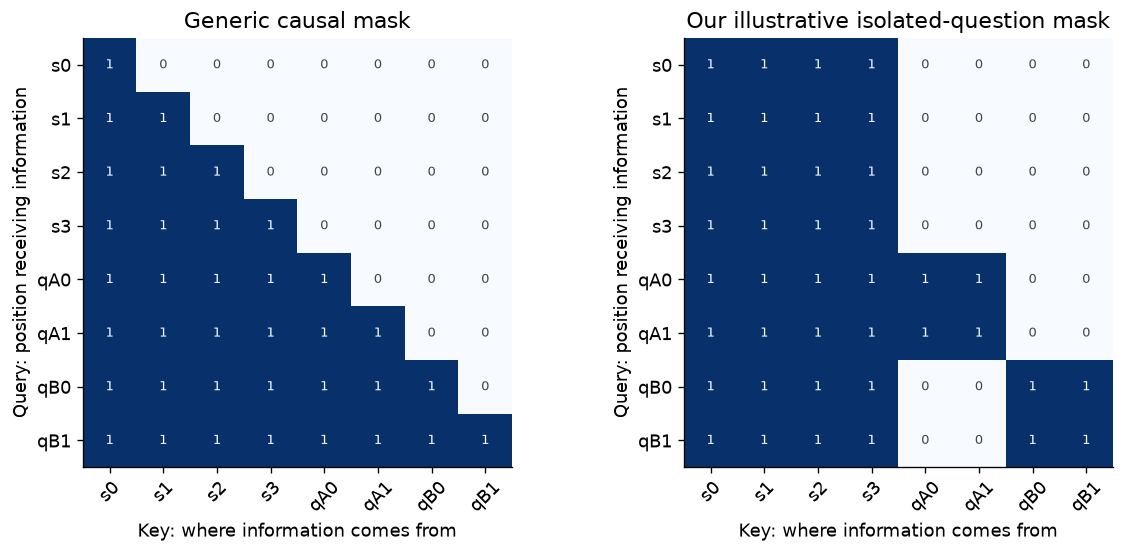

In [4]:
state_length, question_length = 4, 2
length = state_length + 2 * question_length
allowed = np.zeros((length, length), dtype=bool)
allowed[:state_length, :state_length] = True
for start in [4, 6]:
    allowed[start:start+2, :state_length] = True
    allowed[start:start+2, start:start+2] = True
causal = np.tril(np.ones((length, length), dtype=bool))
labels = ['s0', 's1', 's2', 's3', 'qA0', 'qA1', 'qB0', 'qB1']
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, mask, title in zip(axes, [causal, allowed], ['Generic causal mask', 'Our illustrative isolated-question mask']):
    ax.imshow(mask, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(length), labels, rotation=45)
    ax.set_yticks(range(length), labels)
    ax.set(xlabel='Key: where information comes from', ylabel='Query: position receiving information', title=title)
    for row in range(length):
        for col in range(length):
            ax.text(col, row, str(int(mask[row,col])), ha='center', va='center',
                    fontsize=8, color='white' if mask[row,col] else GREY)
show_figure('06_attention_masks')

### 4. Verify isolation by changing the other question
The next function is one attention layer with random, untrained weights. It is not a useful language
model. It lets us verify an information-flow claim exactly: changing question B must not change
question A's output under our mask. Remove the mask and that guarantee disappears.

In [5]:
rng = np.random.default_rng(12)
dimension = 6
embeddings = rng.normal(size=(length, dimension))
Wq, Wk, Wv = [rng.normal(size=(dimension, dimension)) / np.sqrt(dimension) for _ in range(3)]

def attention(x, mask):
    q, k, v = x @ Wq, x @ Wk, x @ Wv
    scores = q @ k.T / np.sqrt(dimension)
    masked_scores = np.where(mask, scores, -np.inf)
    attention_weights = softmax(masked_scores)
    return attention_weights @ v

changed = embeddings.copy()
changed[6:] += 10
isolated_before = attention(embeddings, allowed)
isolated_after = attention(changed, allowed)
full_mask = np.ones_like(allowed)
full_before, full_after = attention(embeddings, full_mask), attention(changed, full_mask)
isolated_change = np.max(np.abs(isolated_before[4:6] - isolated_after[4:6]))
unmasked_change = np.max(np.abs(full_before[4:6] - full_after[4:6]))
print(f'Question A change with our mask: {isolated_change:.12f}')
print(f'Question A change with all connections: {unmasked_change:.4f}')
assert np.allclose(isolated_before[4:6], isolated_after[4:6])
assert not np.allclose(full_before[4:6], full_after[4:6])

Question A change with our mask: 0.000000000000
Question A change with all connections: 17.9544


We also blocked state from reading questions. Otherwise question B could affect state in one layer
and reach question A through state in a later layer. Isolation must hold across the full computation,
not just the final row of one attention matrix. Whether a particular architecture caches, batches,
or computes these blocks efficiently is a separate implementation question.

### 5. Shared computation can reduce repeated work
Suppose state encoding costs $S$ units and each question costs $Q$ units. Repeating everything
for $m$ questions costs $m(S+Q)$. An idealized reusable state costs $S+mQ$.
This models work, not latency; parallel hardware does not make additional computation free.

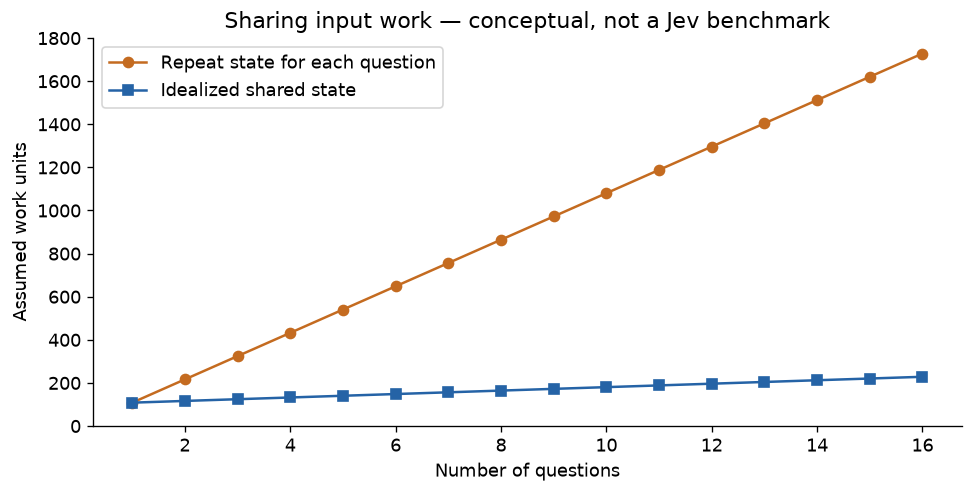

In [6]:
questions = np.arange(1, 17)
state_work, question_work = 100, 8
fig, ax = plt.subplots()
ax.plot(questions, questions * (state_work + question_work), 'o-', color=ORANGE, label='Repeat state for each question')
ax.plot(questions, state_work + questions * question_work, 's-', color=BLUE, label='Idealized shared state')
ax.set(xlabel='Number of questions', ylabel='Assumed work units', title='Sharing input work — conceptual, not a Jev benchmark', ylim=(0, 1800))
ax.legend()
show_figure('06_shared_work')

### 6. Why rewarding only the chosen answer can overstate certainty
Let the true chance of a positive outcome be $q=0.7$. If your objective only rewards choosing the
correct binary label, reporting $p=0.51$ and $p=0.99$ produces the same “yes” action and expected
accuracy. A probabilistic loss also cares how certain you were.

The expected Brier loss is
$$L(p)=q(1-p)^2+(1-q)p^2=(p-q)^2+q(1-q).$$
Its unique minimum is at $p=q$. This is a derivation of a general proper scoring rule.
It helps explain the motivation for calibrated prediction, but does not reveal the RLCD loss or reward.

**Math companion · show why the minimum is honest**

Differentiating the expected binary Brier loss shown above gives
$$\frac{dL}{dp}=2(p-q),\qquad \frac{d^2L}{dp^2}=2>0.$$
Here $q$ is the true positive-outcome rate and $p$ is the reported probability.
The unique minimum occurs at $p=q$, including boundary rates 0 and 1.
For $q=0.7$, the minimum is $q(1-q)=0.21$; irreducible outcome randomness leaves positive
expected loss. This is a worked example of strict propriety, as discussed by
[Gneiting and Raftery (2007)](https://doi.org/10.1198/016214506000001437), not the RLCD reward.

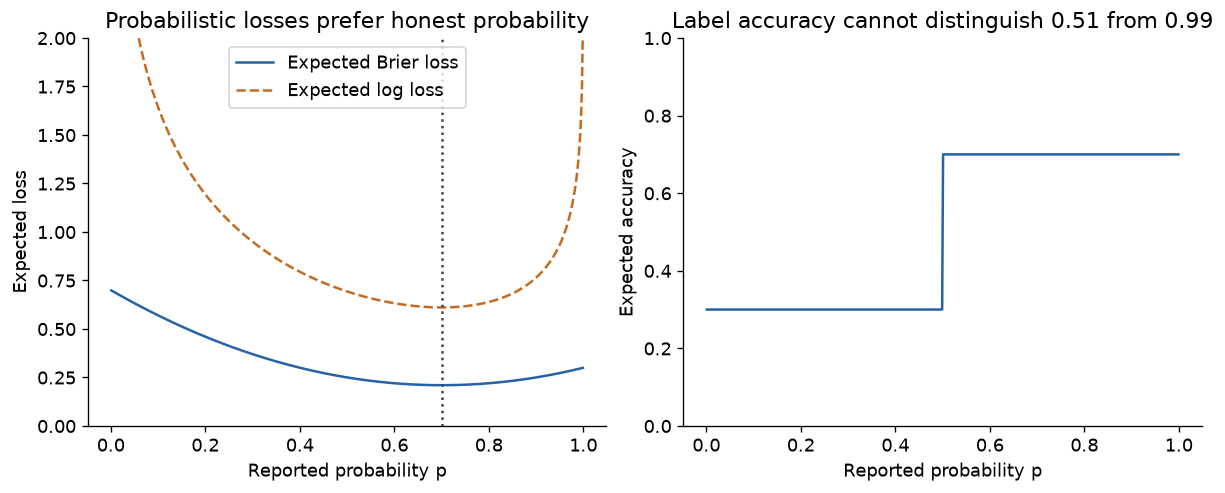

In [7]:
true_rate = .7
reported = np.linspace(.001, .999, 500)
expected_brier = true_rate * (1-reported)**2 + (1-true_rate) * reported**2
expected_log_loss = -true_rate*np.log(reported) - (1-true_rate)*np.log(1-reported)
expected_accuracy = np.where(reported >= .5, true_rate, 1-true_rate)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(reported, expected_brier, color=BLUE, label='Expected Brier loss')
axes[0].plot(reported, expected_log_loss, color=ORANGE, linestyle='--', label='Expected log loss')
axes[0].axvline(true_rate, color=GREY, linestyle=':')
axes[0].set(xlabel='Reported probability p', ylabel='Expected loss', ylim=(0, 2), title='Probabilistic losses prefer honest probability')
axes[0].legend()
axes[1].plot(reported, expected_accuracy, color=BLUE)
axes[1].set(xlabel='Reported probability p', ylabel='Expected accuracy', ylim=(0,1), title='Label accuracy cannot distinguish 0.51 from 0.99')
show_figure('06_objectives')

### 7. Place RLCD claims in context
RLHF uses human-preference signals; RLVR uses verifiable outcomes; TypeSafe describes RLCD as targeting
calibrated decisions. These are high-level objective descriptions, not complete mutually exclusive
training recipes. A real system may combine multiple training stages and losses.

Without the detailed RLCD algorithm we cannot specify its reward estimator, optimizer, sampling procedure,
or how its calibration generalizes. We can still test the externally visible contract and evaluate its outputs.

## Checks

In [8]:
assert np.all(allowed.sum(axis=1) > 0)
assert np.isclose(expected_brier.min(), true_rate*(1-true_rate), atol=1e-5)
assert np.isclose(softmax(overlap_scores).sum(), 1)
print('Candidate normalization, attention isolation, and scoring-rule minimum checked.')

Candidate normalization, attention isolation, and scoring-rule minimum checked.


## Next Steps
**Exercise 6:** Unblock question A's attention to question B and rerun the isolation test.
Predict which assertion will fail. Explain why “parallel” does not by itself imply “isolated.”

**Exercise 7:** For the assumed work model, derive the speedup in work units as $m$ grows very large.
Why should you avoid interpreting that limit as a promised wall-clock speedup?

Continue to the [text-routing capstone](07_text_routing_capstone.ipynb).

## Take three ideas with you

- Candidate descriptions can be inputs to a scorer; a fixed classifier head works differently.
- Masks govern information flow; scheduling governs parallel execution.
- The demonstrated mechanisms do not reproduce Jev or RLCD.

**You are ready to move on when:** You can describe the attention-mask experiment and state what it does not tell us about Jev.

## Check your understanding

Our attention demo keeps questions separate. Does that prove Jev uses this mask?

Pause and explain your answer before opening the explanation.

<details>
<summary>Show the explanation</summary>
<p>No. The experiment proves a property of our constructed example. A similar external behavior can be implemented in different ways.</p>
</details>

For a short next step, try the [practice questions](../docs/PRACTICE.md).
For runnable exercises, use the [worked exercises](08_exercises_and_solutions.ipynb).

If you are unsure where to go next, use [the course outline](../docs/COURSE.md).

[Assignments](../assignments/README.md) · [Quick reference](../docs/QUICK_REFERENCE.md) · [Course outline](../docs/COURSE.md)

## Paper references

Read these for the general methods used or contrasted in this lesson. They do not establish Jev’s unpublished architecture or RLCD algorithm. The formulas above are code-matched teaching notation unless explicitly attributed.

- **Vaswani et al. (2017).** [Attention Is All You Need](https://arxiv.org/abs/1706.03762). Advances in Neural Information Processing Systems 30. Scaled dot-product attention and the need to supply position information.

- **Devlin et al. (2019).** [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://aclanthology.org/N19-1423/). NAACL-HLT:4171–4186. Contextual language representations and downstream classification; BERT is not run in this course.

- **Gneiting and Raftery (2007).** [Strictly Proper Scoring Rules, Prediction, and Estimation](https://doi.org/10.1198/016214506000001437). Journal of the American Statistical Association 102(477):359–378. Why proper probability losses reward honest probability forecasts.

[Paper reading guide and equation map](../docs/PAPER_GUIDE.md) · [Jev documentation and source limits](../docs/SOURCES.md).